# Notebook 03 — Baseline Models

**Day 3 deliverable.** Trains Logistic Regression, Random Forest, and XGBoost independently. Reports top-1 accuracy, top-3 accuracy, and macro-F1 for each. Saves all three models.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
# Classification that calculates probability of a patient having multiple diseases based on symptoms so 
# as to not focus on one before tests are run to narrow it down.
from sklearn.ensemble import RandomForestClassifier 
# Random forest uses different symptoms iteratively, so as to reduce overfitting and bias towards certain symptoms.
from xgboost import XGBClassifier
# XGBoost is a gradient boosting algorithm that uses decision trees to improve accuracy and reduce overfitting.
# Gradient boosting is a technique that builds models sequentially, with each new model attempting to correct the errors of the previous models.
# Basically adjusting weights of previous models to improve accuracy and reduce overfitting.
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Cross-validation is a technique used to evaluate the performance of a model by 
# splitting the data into multiple subsets and training/testing the model on different combinations 
# of these subsets.
# Ensures no bias of samples 
from sklearn.metrics import (
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'

sns.set_theme(style='whitegrid')

In [2]:
train_df     = pd.read_csv(PROC / 'train_clean.csv')
test_df      = pd.read_csv(PROC / 'test_clean.csv')
feature_cols = joblib.load(PROC / 'feature_cols.pkl')
le           = joblib.load(PROC / 'label_encoder.pkl')

X_train = train_df[feature_cols].values
y_train = le.transform(train_df['prognosis'])
X_test  = test_df[feature_cols].values
y_test  = le.transform(test_df['prognosis'])

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}  |  Classes: {len(le.classes_)}')

Train: (355, 142)  |  Test: (50, 142)  |  Classes: 49


## Helper — Top-k Accuracy

In [3]:
def top_k_accuracy(model, X, y, k=3):
    probs      = model.predict_proba(X)
    top_k_pred = np.argsort(probs, axis=1)[:, -k:]
    return float(np.mean([y[i] in top_k_pred[i] for i in range(len(y))]))


def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model':     name,
        'Top-1 Acc': round(accuracy_score(y_te, y_pred), 4),
        'Top-3 Acc': round(top_k_accuracy(model, X_te, y_te, k=3), 4),
        'Macro-F1':  round(f1_score(y_te, y_pred, average='macro'), 4),
    }

## Train Baseline Models

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
# Since it is labled data, we can use supervised learning algorithms like logistic regression, random forest, 
# and XGBoost to predict the probability of a patient having multiple diseases based on symptoms.
# Reduces variance as it uses regularization to prevent overfitting and bias towards certain symptoms.
# It also a simple enough model for small to medium datasets, which is the case here. 
# It also outputs probabilities for each class, which is useful for multi-class classification.
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
# Reduces problem of trees by using multiple trees and averaging their predictions, 
# which reduces overfitting and bias towards certain symptoms.
# Uses multiple features(symptoms) and samples(cross validation) to reduce overfitting and
#  bias towards certain symptoms.
xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42, verbosity=0,
)
# ensemple method(using multiple models i.e XGB Boosting which is a decision tree that corrects previous errors in different trees) that uses 
# gradient boosting to improve accuracy and reduce overfitting.

results = []
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    print(f'Training {name}...')
    results.append(evaluate(name, model, X_train, y_train, X_test, y_test))
# Top 1 predicts whether the model is correct in its top prediction.
# Macro-F1 measures whether the models is correct in its prediction
# of multiple classes(disease) prediction.

metrics_df = pd.DataFrame(results)
# Top 3 accuracy measures the whether the correct disease appears in top 3 
# even if the model is wrong in top prediction.
print()
print(metrics_df.to_string(index=False))

Training Logistic Regression...


Training Random Forest...


Training XGBoost...



              Model  Top-1 Acc  Top-3 Acc  Macro-F1
Logistic Regression       1.00        1.0    1.0000
      Random Forest       0.98        1.0    0.9864
            XGBoost       0.98        1.0    0.9864


## 5-Fold Cross-Validation

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('LR', lr), ('RF', rf), ('XGB', xgb)]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    print(f'{name:4s}  CV macro-F1: {scores.mean():.4f} +/- {scores.std():.4f}')

LR    CV macro-F1: 0.9918 +/- 0.0109


RF    CV macro-F1: 0.9869 +/- 0.0200


XGB   CV macro-F1: 0.7615 +/- 0.0214


## Metrics Comparison Chart

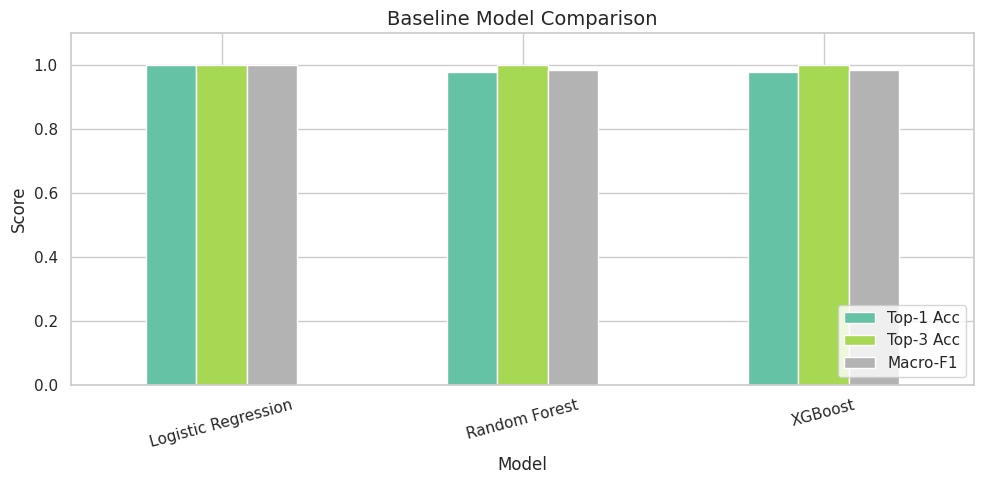

In [6]:
ax = metrics_df.set_index('Model').plot(
    kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white'
)
ax.set_title('Baseline Model Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(PROC / 'plot_baseline_comparison.png', dpi=150)
plt.show()

## Confusion Matrix — Random Forest

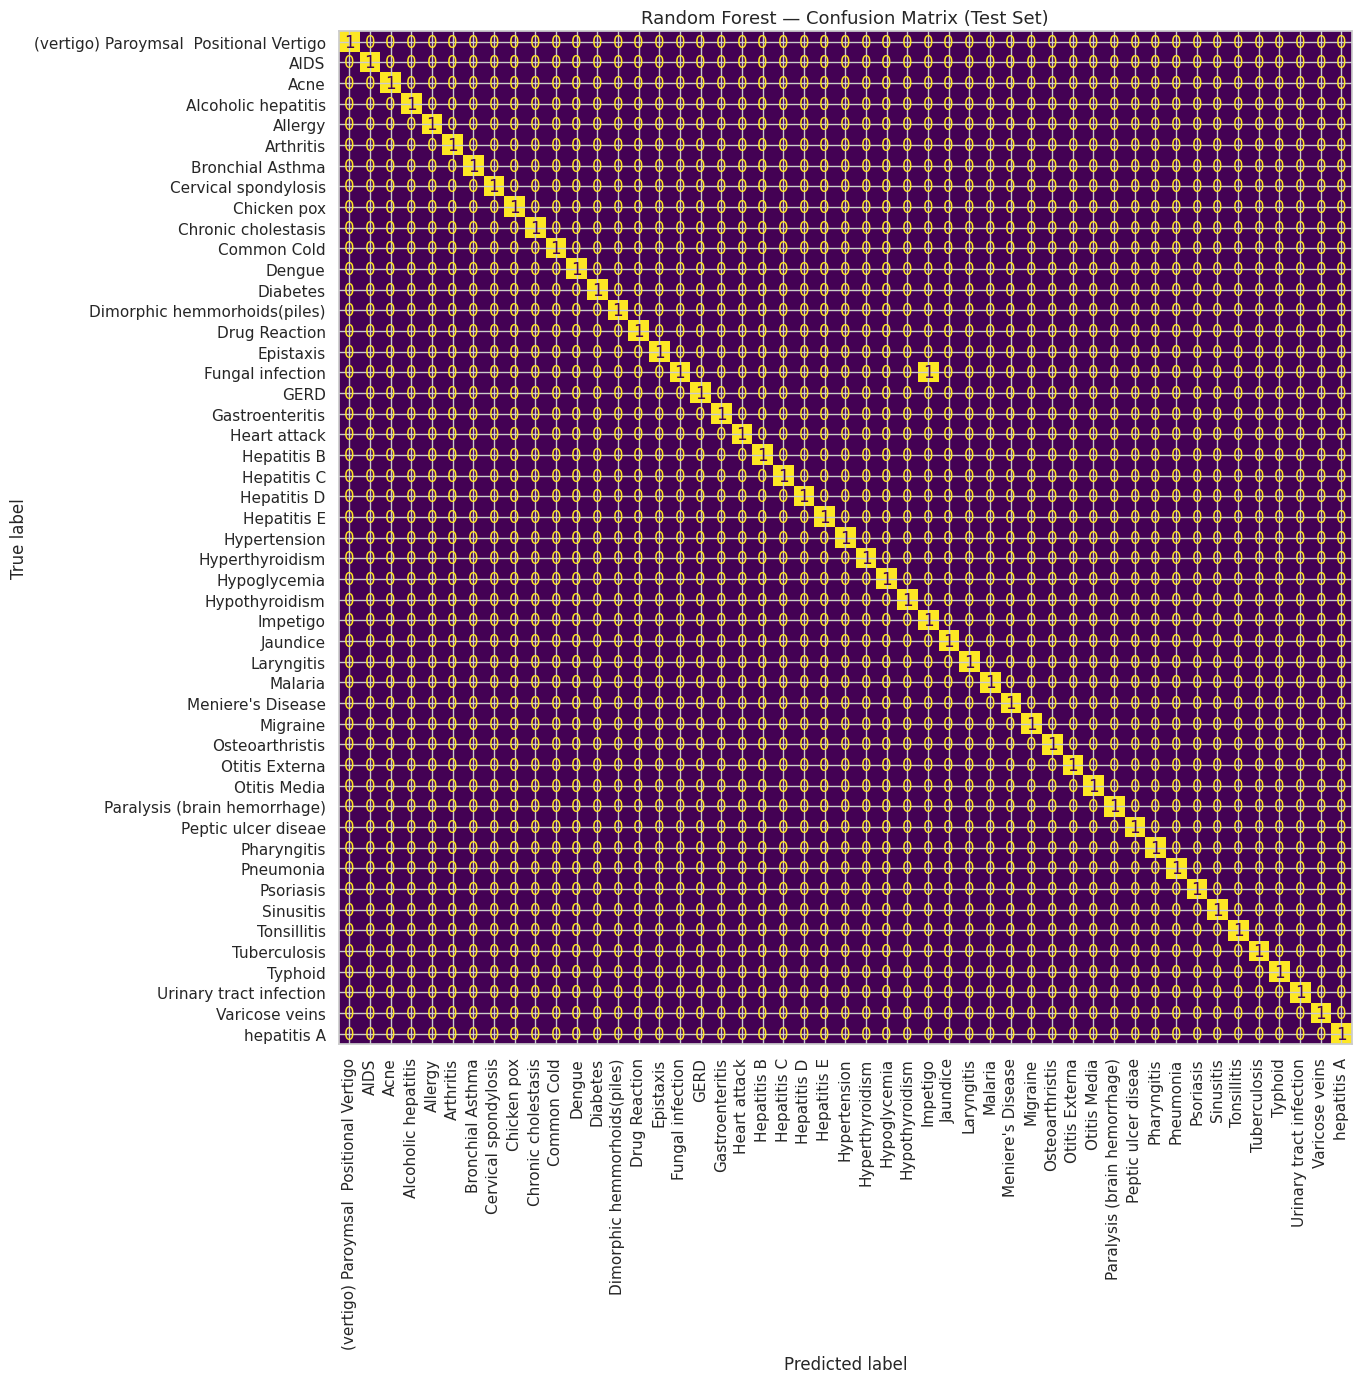

In [7]:
fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf.predict(X_test),
    display_labels=le.classes_,
    ax=ax, xticks_rotation=90, colorbar=False,
)
ax.set_title('Random Forest — Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(PROC / 'plot_confusion_matrix_rf.png', dpi=150)
plt.show()

## Feature Importance — Random Forest

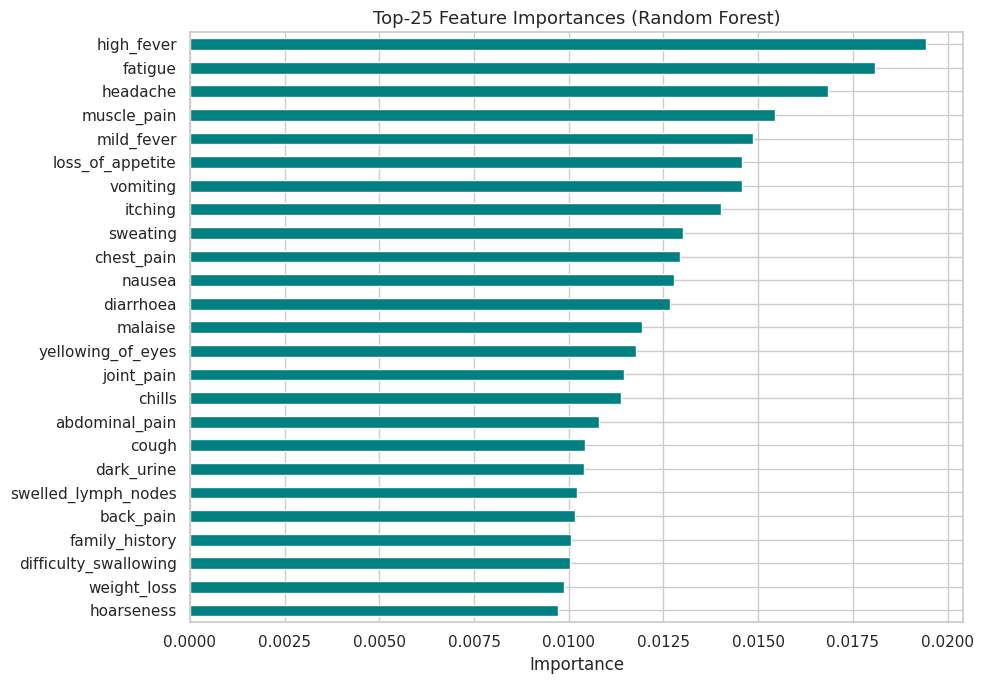

In [8]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).nlargest(25)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_title('Top-25 Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(PROC / 'plot_feature_importance.png', dpi=150)
plt.show()

## Save Models

In [9]:
joblib.dump(lr,  PROC / 'model_lr.pkl')
joblib.dump(rf,  PROC / 'model_rf.pkl')
joblib.dump(xgb, PROC / 'model_xgb.pkl')

print('Saved: model_lr.pkl, model_rf.pkl, model_xgb.pkl')
print('Proceed to 04_ensemble_treatment.ipynb')

Saved: model_lr.pkl, model_rf.pkl, model_xgb.pkl
Proceed to 04_ensemble_treatment.ipynb
